## **Financial Fraud Detection: Data Transformation**

insert abstract similar to main README file

---
### **1. Imports**

In [1]:
# Importing sys to ensure proper environment setup
import sys

!{sys.executable} -m pip install lightgbm

print(sys.version_info)

sys.version_info(major=3, minor=11, micro=14, releaselevel='final', serial=0)


In [2]:
# Importing pandas and numpy for numerical analysis
# Importing pyplot and seaborn to visualize the data
# Importing lightgbm as gradient boosting framework for tree based learning algorightms
# Importing os, pathlib, and warnings for functionality, faster loading, flagging exceptions, etc.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import lightgbm as lgb
import os # possibly remove
from pathlib import Path
from scipy.stats import multivariate_normal, norm, trim_mean, zscore
import warnings
warnings.filterwarnings('ignore')

# Importing sklearn items for model training & testing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_recall_curve, precision_score, classification_report,
    confusion_matrix, mean_absolute_error, accuracy_score, recall_score, f1_score, 
    roc_curve, roc_auc_score, precision_recall_fscore_support)

%matplotlib inline

sns.set(style="whitegrid", palette="muted", font_scale=1.25)

print("Setup Complete")

Setup Complete


---
### **2 Load Data & Quick Review**

In [3]:
# Dealing with plathform-specific issues that may cause errors
# For systems that use backslash (\) characters instead of forward (/) slash
from pathlib import Path, PureWindowsPath

# Explicity noting path as being in Windows format so I can use forward slash
filename = PureWindowsPath("C:\\Users\\Winni\\Downloads\\PS_2017_log.csv")

# Convert path to the correct format
file_path = Path(filename)

# Loading data as a DataFrame
df = pd.read_csv(file_path) 

# Using head() function to display the first five rows of the data
print("Heads")
print(df.head())

print()

# Using tail() function to display the last five rows of the data
print("Tails")
print(df.tail())

Heads
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Tails
         step      type      amount     nameOrig  oldbalanceOrg  \
6362615   743  CASH_OUT  

In [4]:
# Using info() function to review column names, data types, and other relevant information.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
# Creating a function to remove extra leading and trailing whitespace
# Passing DataFrame as a parameter to accomplish this

def whitespace_remover(df):

    # interating over the columns
    for i in df.columns:

        # checking datatype of each column
        if df[i].dtype == 'object':

            # applying strip function on column
            df[i] = df[i].map(str.strip)
        else: 

            # if condition is false, then it'll skip it
            pass

# Applying whitespace_remover function on DataFrame
whitespace_remover(df)

# Filter on all values not stored as str in 'type' column
df['type'].map(type) != str

# Printing value_count()
print(df['type'].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [6]:
# Check for missing values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
# Duplicate values check
df.duplicated().sum()

np.int64(0)

In [8]:
# Sample 15% of data
# sr = df.sample(frac=0.15)

# Verify number of rows
# print(f"Original rows: {len(df)}")
# print(f"Samples rows (15%): {len(sr)}")

# Displaying result
# sr

---
### **3. Alterations & Modifications**

In [9]:
# Dropping irrelevant columns
df = df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])

df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [10]:
# label encoding
le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

print("Label Encoder - Category Mapping:")
print(dict(enumerate(le.classes_)))

# One-Hot Encoding via get_dummies to drop 'type' column)
df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)

print("DF after get_dummies:/n", df.head(5))

Label Encoder - Category Mapping:
{0: 'CASH_IN', 1: 'CASH_OUT', 2: 'DEBIT', 3: 'PAYMENT', 4: 'TRANSFER'}
DF after get_dummies:/n    step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1   9839.64       170136.0       160296.36             0.0   
1     1   1864.28        21249.0        19384.72             0.0   
2     1    181.00          181.0            0.00             0.0   
3     1    181.00          181.0            0.00         21182.0   
4     1  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  isFraud  type_enc  type_CASH_OUT  type_DEBIT  type_PAYMENT  \
0             0.0        0         3              0           0             1   
1             0.0        0         3              0           0             1   
2             0.0        1         4              0           0             0   
3             0.0        1         1              1           0             0   
4             0.0        0         3              0      

---
### **4. Reviewing Updates Made**

In [11]:
# Dropping type_enc column
df = df.drop(columns=['type_enc'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   amount          float64
 2   oldbalanceOrg   float64
 3   newbalanceOrig  float64
 4   oldbalanceDest  float64
 5   newbalanceDest  float64
 6   isFraud         int64  
 7   type_CASH_OUT   int64  
 8   type_DEBIT      int64  
 9   type_PAYMENT    int64  
 10  type_TRANSFER   int64  
dtypes: float64(5), int64(6)
memory usage: 534.0 MB


In [12]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,3.516633e-01,6.511783e-03,3.381461e-01,8.375622e-02
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,4.774895e-01,8.043246e-02,4.730786e-01,2.770219e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


---
### **5. Skews, Outliers, Additional Transformations**

Skewness:
 amount            30.993949
isFraud           27.779538
oldbalanceDest    19.921758
newbalanceDest    19.352302
type_DEBIT        12.270876
oldbalanceOrg      5.249136
newbalanceOrig     5.176884
type_TRANSFER      3.005134
type_PAYMENT       0.684258
type_CASH_OUT      0.621319
step               0.375177
dtype: float64


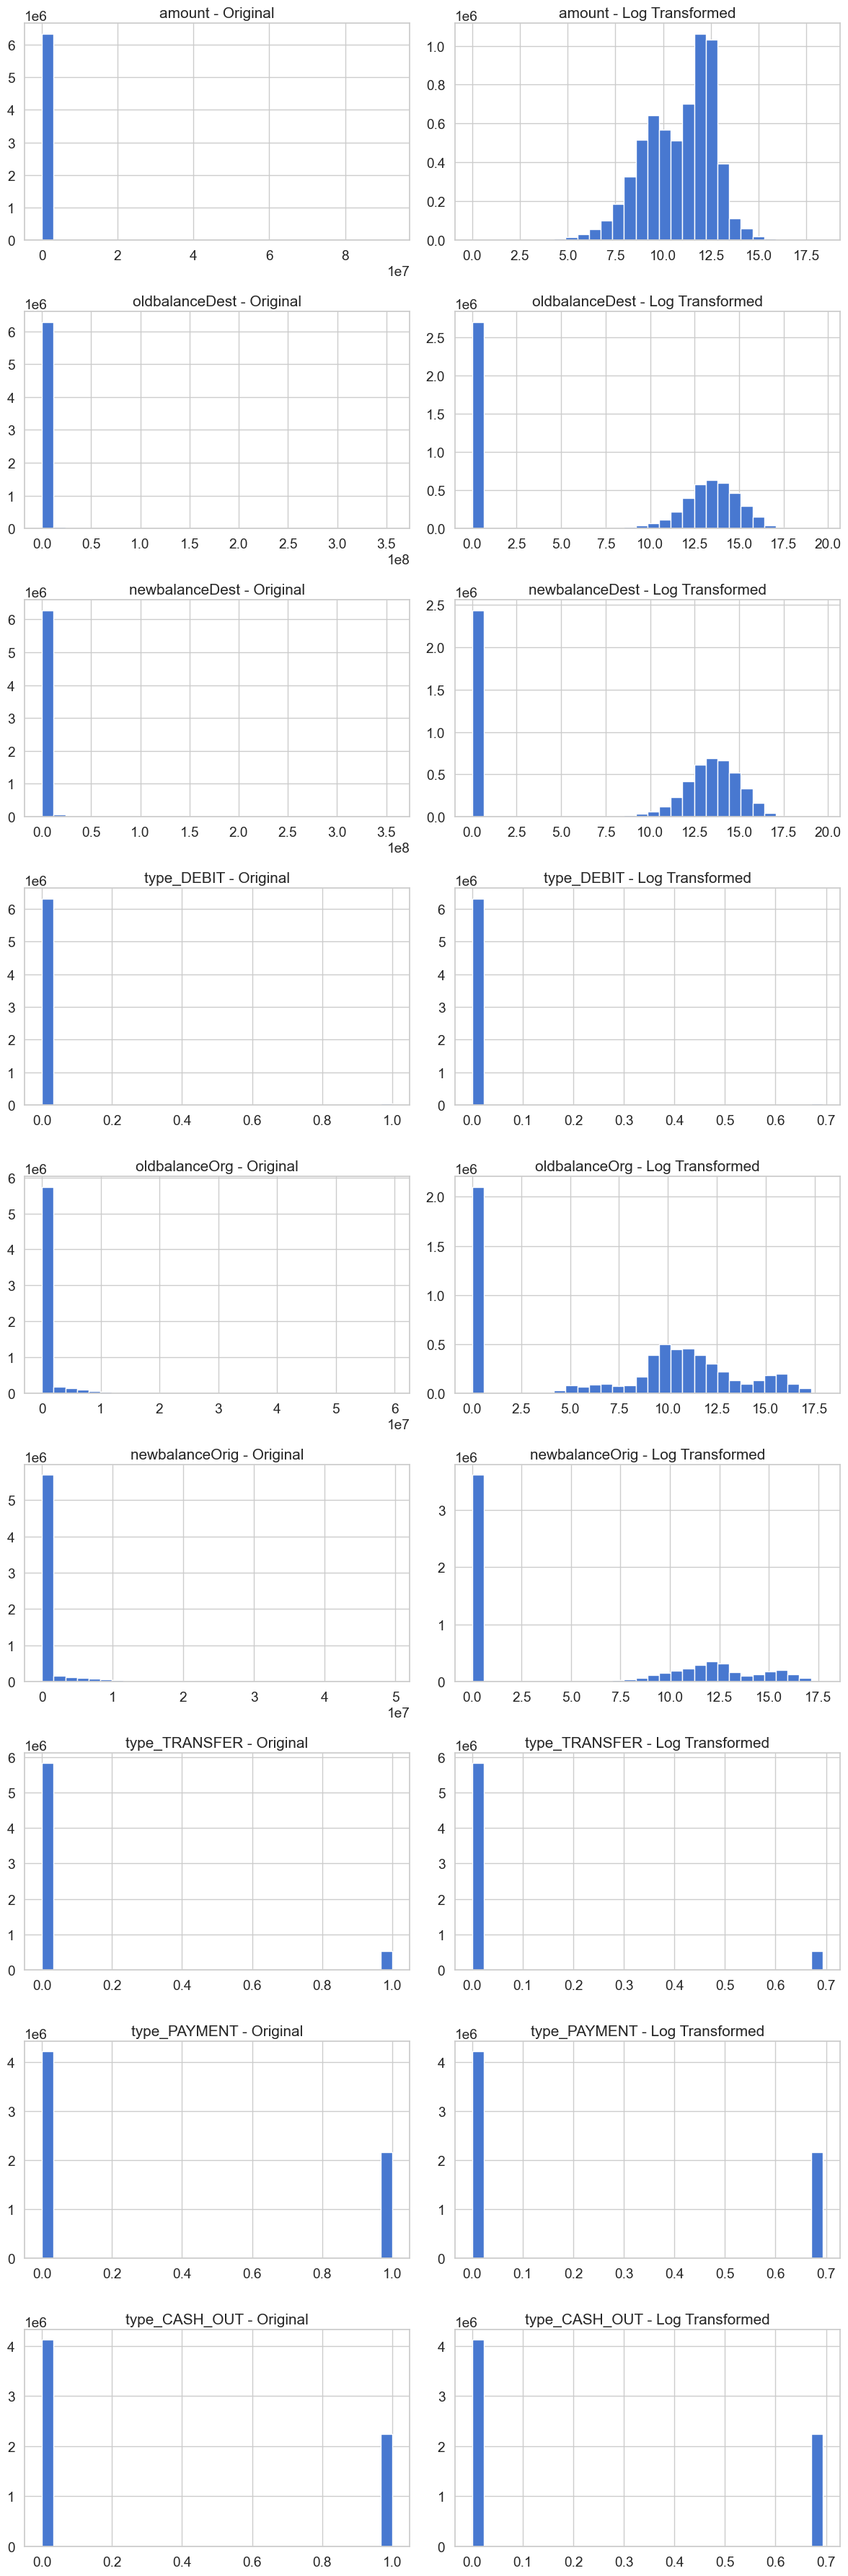

In [13]:
# Visualizing distributions of skewed columns
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
print("Skewness:\n", skewness)

skewed_cols = skewness[abs(skewness) > 0.5].index.tolist()

# Exclude target label from transformation
skewed_cols = [col for col in skewed_cols if col != 'isFraud']

fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(12, 4 * len(skewed_cols)))
for i, col in enumerate(skewed_cols):
    df[col].hist(ax=axes[i, 0], bins=30)
    axes[i, 0].set_title(f'{col} - Original')
    np.log1p(df[col].clip(lower=0)).hist(ax=axes[i, 1], bins=30)
    axes[i, 1].set_title(f'{col} - Log Transformed')
plt.tight_layout()
plt.show()

In [14]:
# Handling outliers with IQR capping at 1.5*IQR boundary (Winsorization)
# Done in lieu of dropping rows, thereby preserving data

for col in skewed_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

# Using log1p again to handle zero values safely
# Only appling it to positively skewed columns (skew > 0.5)
for col in skewed_cols:
    if skewness[col] > 0.5:
        df[col] = np.log1p(df[col])
    elif skewness[col] < -0.5:
        # Reflect then log for negatively skewed
        df[col] = np.log1p(df[col].max() - df[col])

In [15]:
# Checking for any missing values
print(df.isnull().sum())

# For numeric columns, fill with median (robust to outliers)
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# For categorical columns, fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
type_CASH_OUT     0
type_DEBIT        0
type_PAYMENT      0
type_TRANSFER     0
dtype: int64


---
### **6. Verifying Changes**

In [16]:
# Confirm no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print()

# Confirm shape is intact
print("DataFrame shape:\n", df.shape)

# Numeric columns check
print("\nNumeric column stats:")
print(df[num_cols].describe())

Missing values after cleaning:
step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
type_CASH_OUT     0
type_DEBIT        0
type_PAYMENT      0
type_TRANSFER     0
dtype: int64

DataFrame shape:
 (6362620, 11)

Numeric column stats:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.080461e+01   7.046598e+00    5.038014e+00   
std    1.423320e+02  1.754084e+00   5.214558e+00    5.847248e+00   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  9.502306e+00   0.000000e+00    0.000000e+00   
50%    2.390000e+02  1.122355e+01   9.561631e+00    0.000000e+00   
75%    3.350000e+02  1.224876e+01   1.158353e+01    1.187937e+01   
max    7.430000e+02  1.312580e+01   1.249982e+01    1.279565e+01   

       oldbalanceDest  newbalanceDest       isFraud  type_CASH_OUT 

---
### **7. Save Cleaned CSV**

In [17]:
# Explicity noting path as being in Windows format so I can use forward slash
clean = PureWindowsPath("C:\\Users\\Winni\\fin-fraud-detect\\Data\\cleaned.csv")

# Convert path to the correct format
file_path = Path(clean)

# Saving data as a DataFrame
df.to_csv(file_path, index=False)
# index=False prevents pandas from saving row numbers as a column
print("Saved successfully!")

Saved successfully!


In [18]:
# Most reliable confirmation is to reload
clean = PureWindowsPath("C:\\Users\\Winni\\fin-fraud-detect\\Data\\cleaned.csv")
file_path = Path(clean)

df_clean = pd.read_csv(file_path)

print("Shape:", df_clean.shape)
print("Missing values:\n", df_clean.isnull().sum())
print("\nPreview:\n", df_clean.head())

Shape: (6362620, 11)
Missing values:
 step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
type_CASH_OUT     0
type_DEBIT        0
type_PAYMENT      0
type_TRANSFER     0
dtype: int64

Preview:
    step    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1  9.194276      12.044359       11.984786        0.000000   
1     1  7.531166       9.964112        9.872292        0.000000   
2     1  5.204007       5.204007        0.000000        0.000000   
3     1  5.204007       5.204007        0.000000        9.960954   
4     1  9.364703      10.634773       10.305174        0.000000   

   newbalanceDest  isFraud  type_CASH_OUT  type_DEBIT  type_PAYMENT  \
0             0.0        0       0.000000         0.0      0.693147   
1             0.0        0       0.000000         0.0      0.693147   
2             0.0        1       0.000000         0.0      0.000000   
3             0.0        

### **Observations**
<br>
ABC